# Task 3 — Confidence Interval for σ₁²/σ₂², Means Unknown

We have two independent samples $X_1,\ldots,X_n \sim \mathcal{N}(\mu_1, \sigma_1^2)$ and $Y_1,\ldots,Y_m \sim \mathcal{N}(\mu_2, \sigma_2^2)$ with **both means unknown**. We want a confidence interval for $\tau = \sigma_1^2/\sigma_2^2$.

## Deriving the Interval

Since the means are unknown, we work with the sample variances. Recall that:

$$
\frac{(n-1)S_X^2}{\sigma_1^2} \sim \chi^2_{n-1}, \qquad \frac{(m-1)S_Y^2}{\sigma_2^2} \sim \chi^2_{m-1}
$$

where $S^2$ denotes the **unbiased** sample variance. Taking their ratio gives an F-distributed pivot:

$$
F = \frac{S_X^2 / \sigma_1^2}{S_Y^2 / \sigma_2^2} = \frac{S_X^2}{S_Y^2} \cdot \frac{\sigma_2^2}{\sigma_1^2} \sim F(n-1,\, m-1)
$$

Note the connection to the pivot suggested in the problem sheet. Using $\operatorname{Var}(\cdot)$ for the **biased** estimator:

$$
\frac{n(m-1)\operatorname{Var}(X)}{m(n-1)\operatorname{Var}(Y)} = \frac{S_X^2 / \sigma_1^2}{S_Y^2 / \sigma_2^2} \cdot \frac{\sigma_1^2}{\sigma_2^2} \cdot \frac{1}{\tau}
$$

which confirms the same F-pivot.

For a two-sided interval at level $1-\alpha$, let $f_{\alpha/2}$ and $f_{1-\alpha/2}$ be quantiles of $F(n-1, m-1)$:

$$
P\!\left(f_{\alpha/2} \le \frac{S_X^2}{S_Y^2}\cdot\frac{1}{\tau} \le f_{1-\alpha/2}\right) = 1 - \alpha
$$

Rearranging for $\tau$:

$$
\boxed{\tau \in \left[\frac{S_X^2}{S_Y^2 \cdot f_{1-\alpha/2}},\; \frac{S_X^2}{S_Y^2 \cdot f_{\alpha/2}}\right]}
$$

## Experiment

Parameters: $\mu_1=0,\ \mu_2=0,\ \sigma_1^2=2,\ \sigma_2^2=1$, so the true $\tau = 2$.

We repeat 1000 times at two sample sizes — $n=m=25$ and $n=m=10000$ — and count how often the 95% CI covers the true value.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "axes.titleweight": "bold",
    "grid.alpha": 0.3,
    "font.family": "DejaVu Sans",
})

# ── Parameters ────────────────────────────────────────────────────────────────
mu1, mu2     = 0, 0
var1, var2   = 2, 1
tau_true     = var1 / var2          # = 2
alpha        = 0.05
n_sim        = 1000
rng          = np.random.default_rng(0)

def run_experiment(n, m):
    lowers, uppers, covers = [], [], []
    f_lo = stats.f.ppf(alpha/2,     n-1, m-1)
    f_hi = stats.f.ppf(1 - alpha/2, n-1, m-1)

    for _ in range(n_sim):
        X = rng.normal(mu1, np.sqrt(var1), n)
        Y = rng.normal(mu2, np.sqrt(var2), m)

        Sx2 = X.var(ddof=1)
        Sy2 = Y.var(ddof=1)
        ratio = Sx2 / Sy2

        lo = ratio / f_hi
        hi = ratio / f_lo

        lowers.append(lo)
        uppers.append(hi)
        covers.append(lo <= tau_true <= hi)

    coverage = 100 * np.mean(covers)
    return np.array(lowers), np.array(uppers), np.array(covers), coverage

lowers_25,    uppers_25,    covers_25,    cov_25    = run_experiment(25,    25)
lowers_10000, uppers_10000, covers_10000, cov_10000 = run_experiment(10000, 10000)

print(f"n=25    — coverage: {cov_25:.1f}%")
print(f"n=10000 — coverage: {cov_10000:.1f}%")

n=25    — coverage: 95.1%
n=10000 — coverage: 94.1%


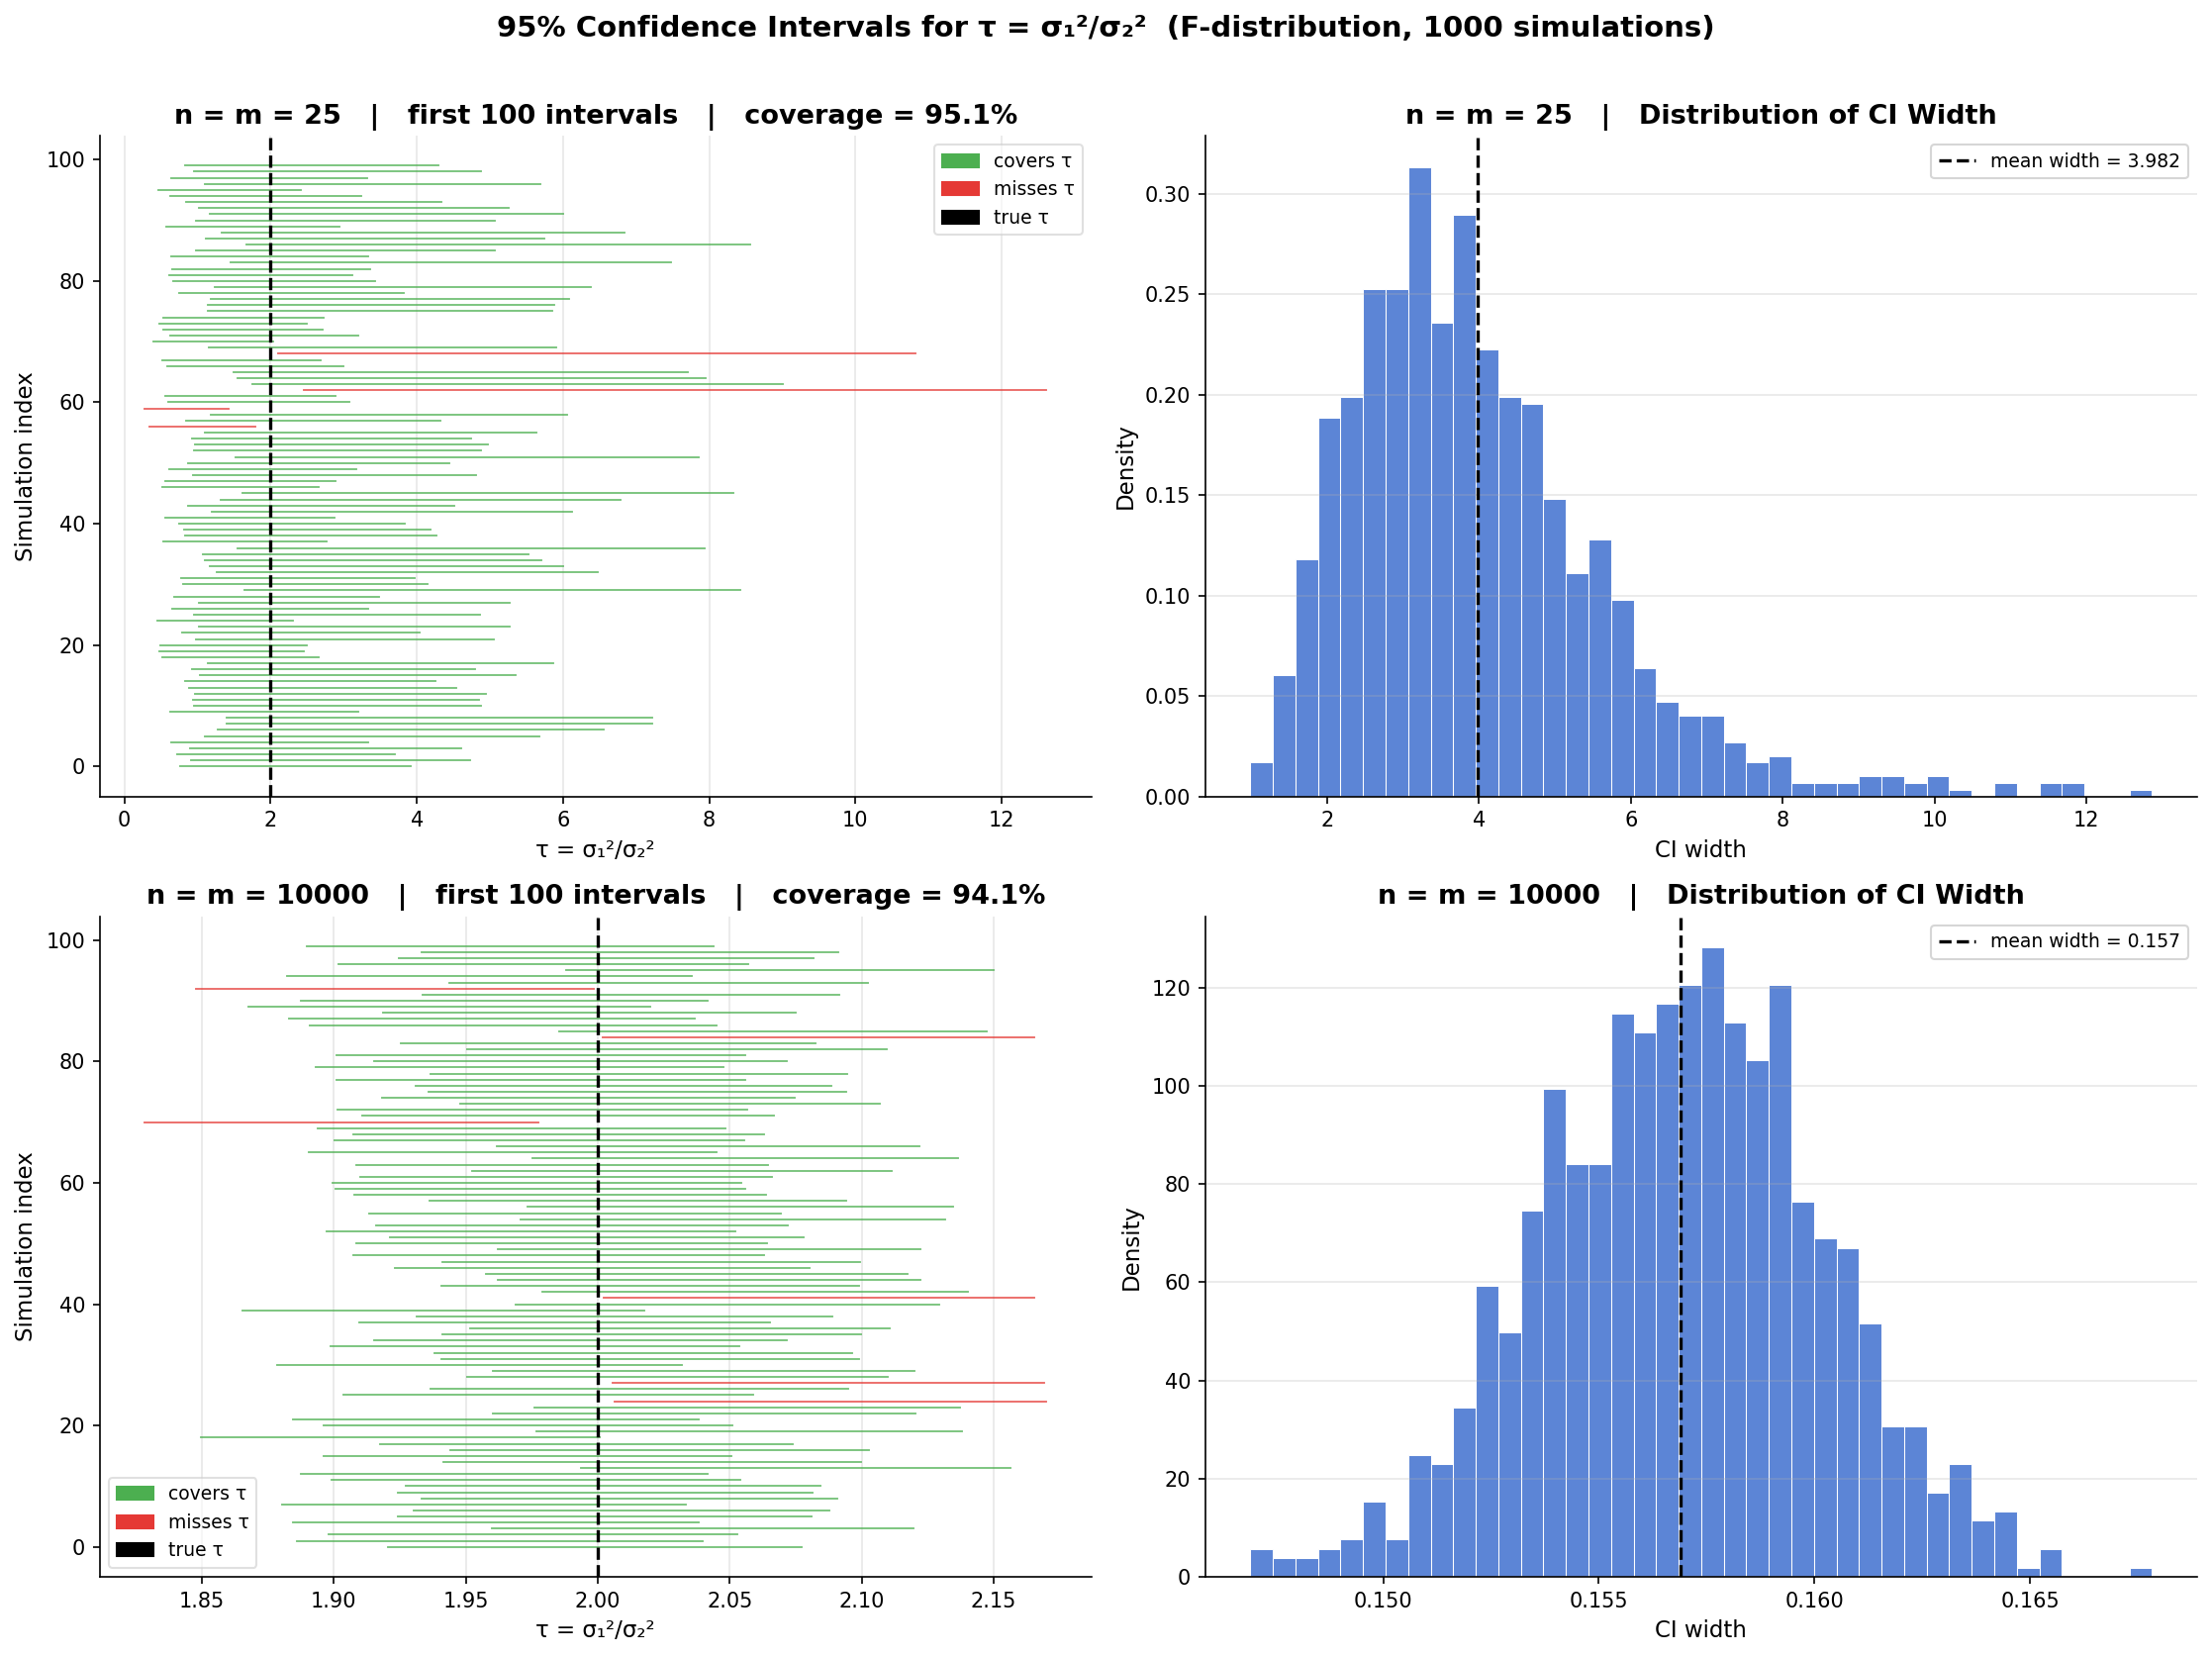

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("95% Confidence Intervals for τ = σ₁²/σ₂²  (F-distribution, 1000 simulations)",
             fontsize=14, fontweight="bold", y=1.01)

c_hit  = "#4CAF50"
c_miss = "#E53935"

for row, (n, lowers, uppers, covers, cov) in enumerate([
        (25,    lowers_25,    uppers_25,    covers_25,    cov_25),
        (10000, lowers_10000, uppers_10000, covers_10000, cov_10000)]):

    # ── Left: first 100 intervals ─────────────────────────────────────────────
    ax = axes[row, 0]
    show = 100
    for i in range(show):
        color = c_hit if covers[i] else c_miss
        ax.plot([lowers[i], uppers[i]], [i, i], color=color, lw=0.9, alpha=0.75)
    ax.axvline(tau_true, color="black", lw=1.6, ls="--", label=f"true τ = {tau_true}")
    ax.set_xlabel("τ = σ₁²/σ₂²")
    ax.set_ylabel("Simulation index")
    ax.set_title(f"n = m = {n}   |   first {show} intervals   |   coverage = {cov:.1f}%")
    hit_patch  = mpatches.Patch(color=c_hit,  label="covers τ")
    miss_patch = mpatches.Patch(color=c_miss, label="misses τ")
    ax.legend(handles=[hit_patch, miss_patch,
                        mpatches.Patch(color="black", label="true τ")],
              fontsize=9, framealpha=0.6)
    ax.grid(axis="x")

    # ── Right: distribution of CI width ──────────────────────────────────────
    ax = axes[row, 1]
    widths = uppers - lowers
    ax.hist(widths, bins=40, color="#5C85D6", edgecolor="white",
            linewidth=0.5, density=True)
    ax.axvline(widths.mean(), color="black", lw=1.6, ls="--",
               label=f"mean width = {widths.mean():.3f}")
    ax.set_xlabel("CI width")
    ax.set_ylabel("Density")
    ax.set_title(f"n = m = {n}   |   Distribution of CI Width")
    ax.legend(fontsize=9)
    ax.grid(axis="y")

plt.tight_layout()
plt.savefig("../results/figures/task3_ci_ftest.png", bbox_inches="tight", dpi=180)
plt.show()

## Discussion

Both sample sizes achieve close to the nominal 95% coverage, which confirms the interval is correctly derived.

The key difference is in **interval width**. At $n=25$ the intervals are wide — there is substantial uncertainty in estimating a variance ratio from only 25 observations. At $n=10000$ the intervals become very tight, converging on the true value $\tau=2$ from both sides. This is visible both in the interval plots and the width histograms.

The slight drop in coverage at $n=10000$ (94.1% vs 95.1%) is just Monte Carlo noise — with 1000 repetitions the standard error on a coverage estimate is roughly $\sqrt{0.95 \cdot 0.05 / 1000} \approx 0.7\%$, so both results are consistent with the true 95% level.